In [3]:
import os
import sys
from pathlib import Path

PROJECT_MARKERS = ("src", "data", "prompts", "results")

def find_project_root(start_path):
    current = os.path.abspath(start_path)

    while True:
        if all(os.path.isdir(os.path.join(current, m)) for m in PROJECT_MARKERS):
            return current

        parent = os.path.dirname(current)
        if parent == current:
            raise RuntimeError("Project root not found")

        current = parent


# ---- execution directory (cwd) ----
cwd = os.getcwd()

# ---- safe starting point ----
try:
    start_path = os.path.dirname(os.path.abspath(__file__))
except NameError:
    start_path = cwd


# ---- resolve canonical paths ----
project_root = find_project_root(start_path)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

src_root     = os.path.join(project_root, "src", "daniel", "gemini")
data_root    = os.path.join(project_root, "data", "MAMS-ACSA", "raw", "data_jsonl","annotated",)
schemas_root = os.path.join(project_root, "data", "MAMS-ACSA", "raw", "data_jsonl", "schema")
prompts_root = os.path.join(project_root, "prompts", "daniel", "llama")
utils_root   = os.path.join(project_root, "utils")
results_root = os.path.join(project_root, "results", "daniel","training_results")

print(
    f"cwd          : {cwd}\n"
    f"Project root : {project_root}\n"
    f"Source root  : {src_root}\n"
    f"Data root    : {data_root}\n"
    f"Prompts root : {prompts_root}\n"
    f"Utils root   : {utils_root}\n"
    f"Results root : {results_root}"
)

# File paths (replace with your own)
train_path = Path(data_root) / "train.jsonl"
val_path = Path(data_root) / "val.jsonl"
test_path = Path(data_root) / "test.jsonl"

print(f"Train path: {train_path}")
print(f"Validation path: {val_path}")
print(f"Test path: {test_path}")

cwd          : /Users/hd/Desktop/RCS-Emotion-Prediction-2025/src/daniel/model
Project root : /Users/hd/Desktop/RCS-Emotion-Prediction-2025
Source root  : /Users/hd/Desktop/RCS-Emotion-Prediction-2025/src/daniel/gemini
Data root    : /Users/hd/Desktop/RCS-Emotion-Prediction-2025/data/MAMS-ACSA/raw/data_jsonl/annotated
Prompts root : /Users/hd/Desktop/RCS-Emotion-Prediction-2025/prompts/daniel/llama
Utils root   : /Users/hd/Desktop/RCS-Emotion-Prediction-2025/utils
Results root : /Users/hd/Desktop/RCS-Emotion-Prediction-2025/results/daniel/training_results
Train path: /Users/hd/Desktop/RCS-Emotion-Prediction-2025/data/MAMS-ACSA/raw/data_jsonl/annotated/train.jsonl
Validation path: /Users/hd/Desktop/RCS-Emotion-Prediction-2025/data/MAMS-ACSA/raw/data_jsonl/annotated/val.jsonl
Test path: /Users/hd/Desktop/RCS-Emotion-Prediction-2025/data/MAMS-ACSA/raw/data_jsonl/annotated/test.jsonl


In [4]:
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np

# --- Loading and preparing data ---

# Function to load and flatten jsonl with nested aspects and emotions
def load_and_flatten_data(filepath):
    texts = []
    polarities = []
    aspects = []
    emotions = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            data = json.loads(line)
            text = data["input"]
            outputs = data["output"]
            for out in outputs:
                texts.append(text)
                polarities.append(out["polarity"])
                aspects.append(out["aspect"])
                emotions.append(out["emotion"])
    return texts, polarities, aspects, emotions


# Load data
train_texts, train_polarities, train_aspects, train_emotions = load_and_flatten_data(train_path)
val_texts, val_polarities, val_aspects, val_emotions = load_and_flatten_data(val_path)
test_texts, test_polarities, test_aspects, test_emotions = load_and_flatten_data(test_path)

# # --- Create new features: combine text with aspect and polarity to simplify the model ---
# def combine_features(texts, polarities, aspects):
#     combined = []
#     for t, p, a in zip(texts, polarities, aspects):
#         combined.append(f"{t} [POLARITY_{p.upper()}] [ASPECT_{a.upper()}]")
#     return combined

# train_combined = combine_features(train_texts, train_polarities, train_aspects)
# val_combined = combine_features(val_texts, val_polarities, val_aspects)
# test_combined = combine_features(test_texts, test_polarities, test_aspects)
# --- Create new features: combine text with aspect ONLY ---
def combine_features(texts, aspects):
    combined = []
    for t, a in zip(texts, aspects):
        # We removed [POLARITY_{p.upper()}] from the string
        combined.append(f"{t} [ASPECT_{a.upper()}]")
    return combined

# Updated calls (removed the polarity lists)
train_combined = combine_features(train_texts, train_aspects)
val_combined = combine_features(val_texts, val_aspects)
test_combined = combine_features(test_texts, test_aspects)
# --- Encode emotions as numeric labels ---
label_encoder = LabelEncoder()
all_emotions = train_emotions + val_emotions + test_emotions
label_encoder.fit(all_emotions)

y_train = label_encoder.transform(train_emotions)
y_val = label_encoder.transform(val_emotions)
y_test = label_encoder.transform(test_emotions)

# --- Vectorize text including polarity and aspect ---
vectorizer = TfidfVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(train_combined)
X_val = vectorizer.transform(val_combined)
X_test = vectorizer.transform(test_combined)

# --- Train model ---
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# --- Predictions ---
val_preds = model.predict(X_val)
test_preds = model.predict(X_test)

# --- Reports considering only actually occurring labels ---

unique_labels_val = np.unique(y_val)
target_names_val = label_encoder.inverse_transform(unique_labels_val)

print("Validation classification report:")
print(classification_report(y_val, val_preds,
                            labels=unique_labels_val,
                            target_names=target_names_val))

unique_labels_test = np.unique(y_test)
target_names_test = label_encoder.inverse_transform(unique_labels_test)

print("Test classification report:")
print(classification_report(y_test, test_preds,
                            labels=unique_labels_test,
                            target_names=target_names_test))


Validation classification report:
                precision    recall  f1-score   support

    admiration       0.43      0.15      0.22       130
     annoyance       0.65      0.78      0.71       165
disappointment       0.45      0.27      0.34        91
       disgust       0.00      0.00      0.00         2
mentioned_only       0.61      0.89      0.72       329
       neutral       0.00      0.00      0.00        59
          null       0.00      0.00      0.00         2
  satisfaction       0.31      0.30      0.31       110

      accuracy                           0.56       888
     macro avg       0.31      0.30      0.29       888
  weighted avg       0.50      0.56      0.51       888

Test classification report:
                precision    recall  f1-score   support

    admiration       0.48      0.19      0.28       113
     annoyance       0.61      0.72      0.66       174
disappointment       0.40      0.20      0.26        86
       disgust       0.00      0.00   

/Users/hd/Desktop/RCS-Emotion-Prediction-2025/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/hd/Desktop/RCS-Emotion-Prediction-2025/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/hd/Desktop/RCS-Emotion-Prediction-2025/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

Matrix saved successfully as emotion_report.png


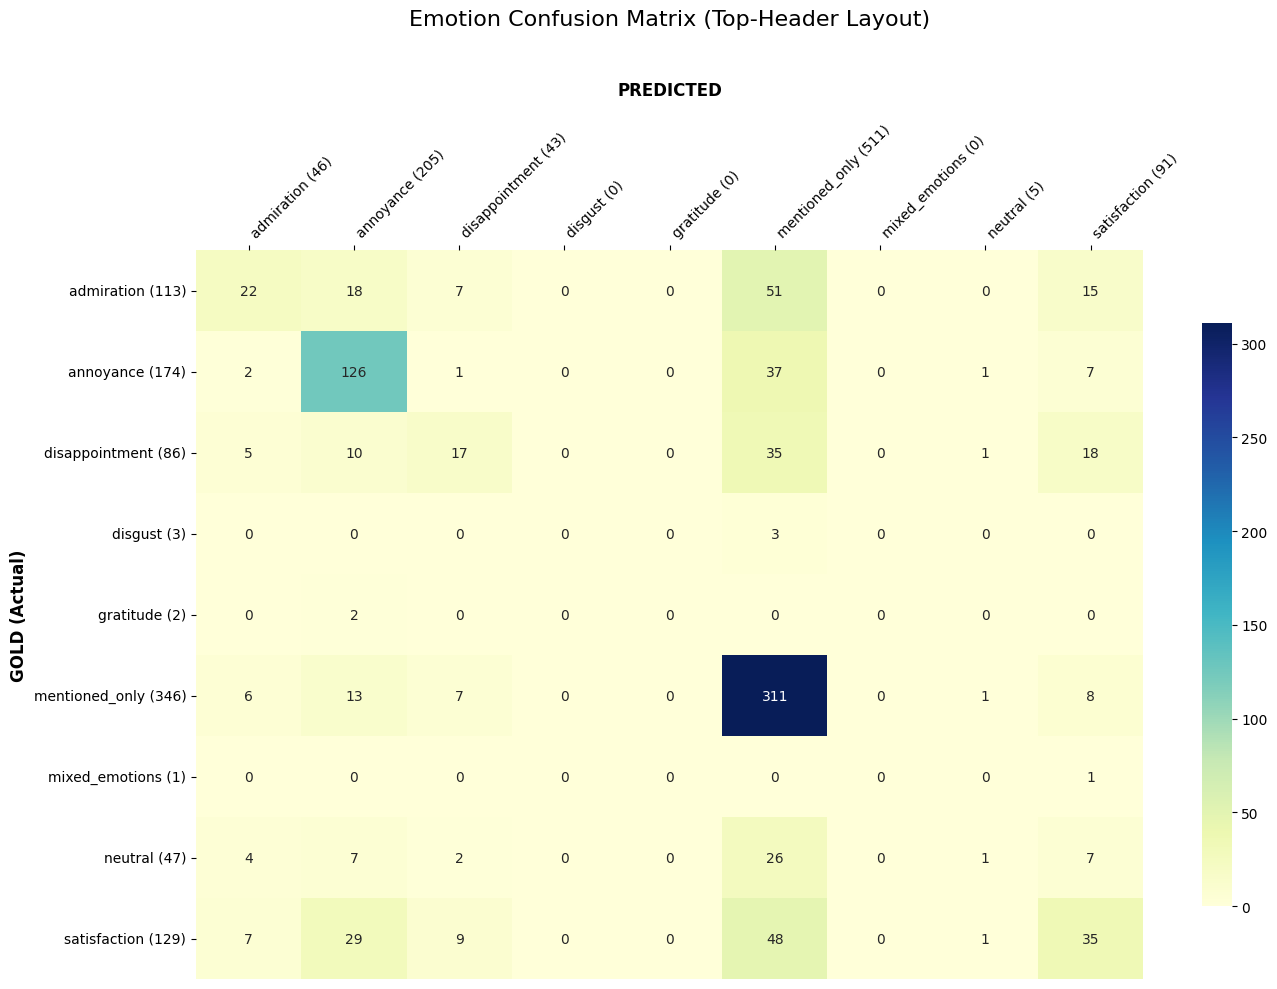

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_top_header_matrix(y_true, y_pred, encoder, title, filename="confusion_matrix.png"):
    # 1. Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # 2. Get labels and calculate support
    unique_labels = np.unique(np.concatenate([y_true, y_pred]))
    label_names = encoder.inverse_transform(unique_labels)
    
    gold_support = [np.sum(y_true == label) for label in unique_labels]
    pred_support = [np.sum(y_pred == label) for label in unique_labels]
    
    y_axis_labels = [f"{name} ({s})" for name, s in zip(label_names, gold_support)]
    x_axis_labels = [f"{name} ({s})" for name, s in zip(label_names, pred_support)]
    
    # 3. Plotting
    plt.figure(figsize=(14, 10))
    ax = sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='YlGnBu',
        xticklabels=x_axis_labels, 
        yticklabels=y_axis_labels,
        cbar_kws={'shrink': .8}
    )
    
    # 4. Move X-axis to the top
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    
    plt.title(title, fontsize=16, pad=40) 
    plt.ylabel('GOLD (Actual)', fontsize=12, fontweight='bold')
    plt.xlabel('PREDICTED', fontsize=12, fontweight='bold', labelpad=20)
    
    plt.xticks(rotation=45, ha='left') 
    plt.tight_layout()
    
    # --- ADDED SAVE STEP ---
    # bbox_inches='tight' is vital to prevent the top labels from being cropped
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Matrix saved successfully as {filename}")
    
    plt.show()

# Run it
plot_top_header_matrix(y_test, test_preds, label_encoder, "Emotion Confusion Matrix (Top-Header Layout)", "emotion_report.png")